# El GHALI Mohamed


## SVM classificaion

#### 1 : Génération du Dataset


In [3]:
import numpy as np
import matplotlib.pyplot as plt

#  Préparation des données

# On veut 100 points en tout
n_samples = 100

# On bloque le hasard pour toujours avoir les mêmes points
np.random.seed(42)

# Création du groupe 1 :
# Des points placés un peu n'importe où autour de l'endroit [2, 2]
X1 = np.random.randn(n_samples // 2, 2) + np.array([2, 2])
#  ces points appartiennent à la catégorie "1"
y1 = np.ones(n_samples // 2)

# Création du groupe 2 :
# Des points placés un peu n'importe où autour de l'endroit [-2, -2]
X2 = np.random.randn(n_samples // 2, 2) + np.array([-2, -2])
#  ces points appartiennent à la catégorie "-1"
y2 = -np.ones(n_samples // 2)

# On met tous les points ensemble dans X
X = np.vstack((X1, X2))

# On met toutes les catégories ensemble dans y
y = np.concatenate((y1, y2))


#### 2 : Fonctions SVM (Entraînement )
Entraîne le SVM en trouvant le vecteur normal (w) et le biais (b) optimaux.
    Retourne les poids w et le biais b.

In [4]:
def entrainer_svm(X, y, learning_rate=0.001, lambda_param=0.01, n_iterations=1000):

    n_samples, n_features = X.shape

    # Initialisation de w  et b  à zéro
    w = np.zeros(n_features)
    b = 0

    # Descente de gradient
    for _ in range(n_iterations):
        for idx, x_i in enumerate(X):

            # Vérification de la marge : y_i * (w.x_i + b) >= 1
            condition = y[idx] * (np.dot(x_i, w) + b) >= 1

            if condition:
                #  Si il est Bien classé on appliquer la régularisation pour maximiser la marge
                dw = 2 * lambda_param * w
                w -= learning_rate * dw
            else:
                # Si il est Mal classé ou dans la marge on corrige w et b
                dw = 2 * lambda_param * w - np.dot(x_i, y[idx])
                db = -y[idx]

                w -= learning_rate * dw
                b -= learning_rate * db

    return w, b

#### 3 : Fonction SVM (Prediction)
Prédit la classe (+1 ou -1) de nouvelles données X en utilisant les paramètres w et b appris.

In [5]:
def predire_svm(X, w, b):

    approximation = np.dot(X, w) + b
    return np.sign(approximation)

#### 4 : Entrainnement des donnees

In [6]:
#cherchons la ligne pour séparer les deux groupes
poids_w, biais_b = entrainer_svm(X, y, learning_rate=0.001, lambda_param=0.01, n_iterations=1000)

#On montre l'angle et la position de la ligne trouvée
print(f"L'angle de ma ligne (w) est : {poids_w}")
print(f"Sa position (b) est : {biais_b}")

#On demande à l'ordi de deviner le groupe de 5 points
predictions = predire_svm(X[:5], poids_w, biais_b)

#On regarde si l'ordi a juste ou s'il s'est trompé
print(f"Ce que l'ordi a deviné : {predictions}")
print(f"La vérité : {y[:5]}")

L'angle de ma ligne (w) est : [0.74478126 0.59598525]
Sa position (b) est : -0.06300000000000004
Ce que l'ordi a deviné : [1. 1. 1. 1. 1.]
La vérité : [1. 1. 1. 1. 1.]


#### 5 : Representation Graphique

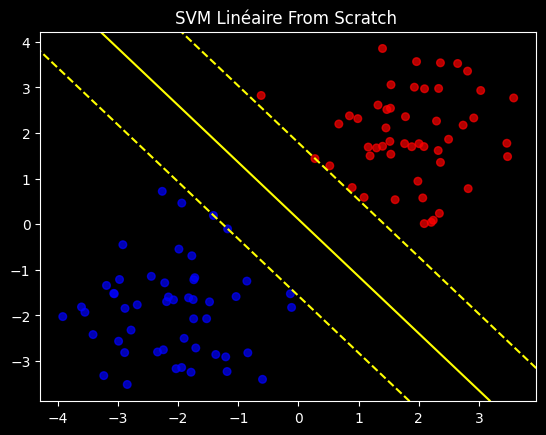

In [7]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=30, alpha=0.7)

# Créer une ensemble des points pour tracer les lignes
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Calculer w.x + b pour toute l'ensemble des points en utilisant notre fonction de prédiction
Z = (np.dot(xy, poids_w) + biais_b).reshape(XX.shape)

# Tracer l'hyperplan (Z=0) et les marges (Z=-1 et Z=1)
ax.contour(XX, YY, Z, colors='yellow', levels=[-1, 0, 1],
            linestyles=['--', '-', '--'])

plt.title("SVM Linéaire From Scratch ")
plt.show()